# 08 — Baselines

Build the comparison floor BEFORE any deep learning.

| Baseline | What it is | Why |
|---|---|---|
| 0 Majority class | always predict the majority | accuracy floor — demonstrates why accuracy alone is meaningless |
| 1 Slope-only LR | logistic regression on ONE number: mean slope | the honest benchmark. Notebook 07 showed slope separates the classes by 0.8 SD, so this will be strong. The CNN must beat it. |
| 2 Handcrafted + RF | per-channel statistics + GLCM texture | classical computer vision, required by Stage 4 of the brief |
| 3 Handcrafted + SVM | same features, RBF kernel | second classical comparator |
| 4 Optical vs terrain | RF on channel subsets | early evidence of where the signal lives |
| 5 Elevation-matched | slope-only LR within the overlapping band | notebook 06 found positives sit 255 m higher. This tests whether performance survives when altitude is controlled. |

All evaluated on the SAME frozen spatial split as the CNN.
Primary metrics: ROC-AUC and PR-AUC. Accuracy reported but not relied on.

In [3]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score,
                             roc_curve)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm.auto import tqdm

PROJECT_DIR = Path("..").resolve()
PROC_DIR    = PROJECT_DIR / "data" / "processed"
METRIC_DIR  = PROJECT_DIR / "outputs" / "metrics"
FIG_DIR     = PROJECT_DIR / "outputs" / "figures"
for d in (METRIC_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
print("imports OK")

imports OK


In [4]:
X     = np.load(PROC_DIR / "X.npy")
y     = np.load(PROC_DIR / "y.npy")
index = pd.read_csv(PROC_DIR / "dataset_index.csv")
stats = json.loads((PROC_DIR / "norm_stats.json").read_text())
CHANNELS = stats["channels"]

tr = (index.split == "train").values
va = (index.split == "val").values
te = (index.split == "test").values

print(f"X {X.shape}   channels {CHANNELS}")
print(f"train {tr.sum()}   val {va.sum()}   test {te.sum()}")
print(f"positive rate — train {y[tr].mean():.1%}  "
      f"val {y[va].mean():.1%}  test {y[te].mean():.1%}")

assert len(X) == len(y) == len(index)
assert np.isfinite(X).all()
assert tr.sum() + va.sum() + te.sum() == len(X)
assert len(np.unique(y[te])) == 2, "test split missing a class"
print("\nCHECKPOINT PASSED")

X (3020, 8, 64, 64)   channels ['B02', 'B03', 'B04', 'B08', 'NDVI', 'slope', 'hillshade', 'curvature']
train 1733   val 650   test 637
positive rate — train 54.6%  val 42.9%  test 44.9%

CHECKPOINT PASSED


In [5]:
# X is z-scored. Invert for the slope channel so the LR coefficient
# is expressed in real degrees.
i_slope = CHANNELS.index("slope")
mu, sd = stats["mean"][i_slope], stats["std"][i_slope]

slope_raw  = X[:, i_slope] * sd + mu
mean_slope = slope_raw.mean(axis=(1, 2))

print(f"mean slope — positive {mean_slope[y==1].mean():.1f}°, "
      f"negative {mean_slope[y==0].mean():.1f}°")
print(f"difference {mean_slope[y==1].mean() - mean_slope[y==0].mean():+.1f}°")
assert 5 < mean_slope.mean() < 45, "implausible slope after inversion"
print("CHECKPOINT PASSED")

mean slope — positive 21.7°, negative 13.2°
difference +8.5°
CHECKPOINT PASSED


In [6]:
def evaluate(name, y_true, prob, thresh=0.5):
    pred = (prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    m = {
        "model": name,
        "roc_auc":  roc_auc_score(y_true, prob),
        "pr_auc":   average_precision_score(y_true, prob),
        "accuracy": (pred == y_true).mean(),
        "balanced_acc": balanced_accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall":    recall_score(y_true, pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        "f1": f1_score(y_true, pred, zero_division=0),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }
    print(f"{name:<26} ROC {m['roc_auc']:.3f}  PR {m['pr_auc']:.3f}  "
          f"bal-acc {m['balanced_acc']:.3f}  recall {m['recall']:.3f}")
    return m

results, curves = [], {}

In [7]:
flat_tr = X[tr].reshape(tr.sum(), -1)
dummy = DummyClassifier(strategy="most_frequent").fit(flat_tr, y[tr])
prob = dummy.predict_proba(X[te].reshape(te.sum(), -1))[:, 1]

results.append(evaluate("0 majority class", y[te], prob))
print(f"\naccuracy {results[-1]['accuracy']:.3f} but recall "
      f"{results[-1]['recall']:.3f} — this is why accuracy alone is useless.")

0 majority class           ROC 0.500  PR 0.449  bal-acc 0.500  recall 1.000

accuracy 0.449 but recall 1.000 — this is why accuracy alone is useless.


In [8]:
slope_lr = make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=1000, random_state=SEED))
slope_lr.fit(mean_slope[tr].reshape(-1, 1), y[tr])
prob = slope_lr.predict_proba(mean_slope[te].reshape(-1, 1))[:, 1]

results.append(evaluate("1 slope-only LR", y[te], prob))
curves["slope-only LR"] = prob

coef = slope_lr.named_steps["logisticregression"].coef_[0, 0]
print(f"\ncoefficient {coef:+.3f}")
assert coef > 0, "NEGATIVE coefficient — steeper predicting LOWER risk. Sign error upstream."

SLOPE_AUC = results[-1]["roc_auc"]
print(f"\n*** TARGET FOR THE CNN: ROC-AUC {SLOPE_AUC:.3f} ***")

1 slope-only LR            ROC 0.789  PR 0.684  bal-acc 0.720  recall 0.832

coefficient +1.856

*** TARGET FOR THE CNN: ROC-AUC 0.789 ***


In [9]:
def extract_features(x):
    """x: (8, 64, 64) normalised -> 1-D feature vector."""
    f = []
    for c in range(x.shape[0]):
        b = x[c]
        f += [b.mean(), b.std(), b.min(), b.max(),
              np.percentile(b, 25), np.percentile(b, 50),
              np.percentile(b, 75), np.percentile(b, 90)]

    # GLCM texture on NIR — classical CV, captures surface roughness
    nir = x[3]
    q = np.clip((nir - nir.min()) / (np.ptp(nir) + 1e-6) * 31, 0, 31).astype(np.uint8)
    g = graycomatrix(q, distances=[1, 3],
                     angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                     levels=32, symmetric=True, normed=True)
    for prop in ("contrast", "homogeneity", "energy", "correlation"):
        f.append(float(graycoprops(g, prop).mean()))

    # spatial variability of slope
    gy, gx = np.gradient(x[5])
    mag = np.hypot(gx, gy)
    f += [float(mag.mean()), float(mag.std())]
    return np.array(f, dtype=np.float32)


F = np.stack([extract_features(x) for x in tqdm(X)])
print(f"features {F.shape}  ({F.shape[1]} per patch)")
assert np.isfinite(F).all(), "non-finite features"
print("CHECKPOINT PASSED")

  0%|          | 0/3020 [00:00<?, ?it/s]

features (3020, 70)  (70 per patch)
CHECKPOINT PASSED


In [10]:
rf = RandomForestClassifier(n_estimators=400, max_depth=12,
                            min_samples_leaf=4, class_weight="balanced",
                            n_jobs=-1, random_state=SEED)
rf.fit(F[tr], y[tr])

print(f"val ROC-AUC {roc_auc_score(y[va], rf.predict_proba(F[va])[:, 1]):.3f}")
prob = rf.predict_proba(F[te])[:, 1]
results.append(evaluate("2 handcrafted + RF", y[te], prob))
curves["handcrafted + RF"] = prob

val ROC-AUC 0.882
2 handcrafted + RF         ROC 0.818  PR 0.759  bal-acc 0.724  recall 0.808


slope_mean        0.0877
slope_p75         0.0873
slope_p50         0.0743
slope_p25         0.0669
slope_p90         0.0616
slope_max         0.0396
slope_std         0.0283
curvature_std     0.0280
curvature_p90     0.0179
slope_grad_std    0.0169
hillshade_p25     0.0159
hillshade_std     0.0147
dtype: float64


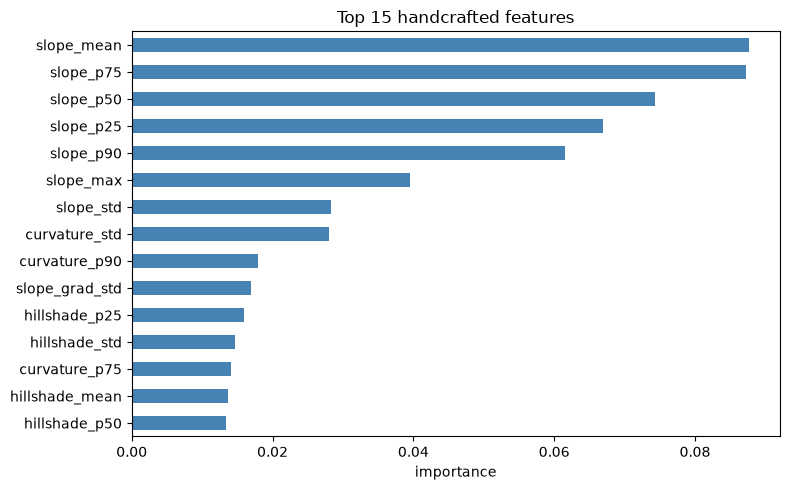


10/10 top features are terrain-derived


In [11]:
names = [f"{c}_{s}" for c in CHANNELS
         for s in ["mean", "std", "min", "max", "p25", "p50", "p75", "p90"]]
names += ["glcm_contrast", "glcm_homogeneity", "glcm_energy",
          "glcm_correlation", "slope_grad_mean", "slope_grad_std"]

imp = pd.Series(rf.feature_importances_, index=names).sort_values(ascending=False)
print(imp.head(12).round(4))

plt.figure(figsize=(8, 5))
imp.head(15)[::-1].plot.barh(color="steelblue")
plt.xlabel("importance"); plt.title("Top 15 handcrafted features")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

top_terrain = imp.head(10).index.str.startswith(("slope", "hillshade", "curvature")).sum()
print(f"\n{top_terrain}/10 top features are terrain-derived")

In [12]:
svm = make_pipeline(StandardScaler(),
                    SVC(kernel="rbf", C=1.0, gamma="scale",
                        class_weight="balanced", probability=True,
                        random_state=SEED))
svm.fit(F[tr], y[tr])
prob = svm.predict_proba(F[te])[:, 1]
results.append(evaluate("3 handcrafted + SVM", y[te], prob))
curves["handcrafted + SVM"] = prob

e:\LandSlide-Prediction\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


3 handcrafted + SVM        ROC 0.826  PR 0.777  bal-acc 0.744  recall 0.836


In [13]:
opt_c = ["B02", "B03", "B04", "B08", "NDVI"]
ter_c = ["slope", "hillshade", "curvature"]

def subset(chan_names):
    idx = [CHANNELS.index(c) for c in chan_names]
    cols = [i*8 + j for i in idx for j in range(8)]
    return F[:, cols]

for tag, chans in (("optical only", opt_c), ("terrain only", ter_c)):
    m = RandomForestClassifier(n_estimators=400, max_depth=12,
                               min_samples_leaf=4, class_weight="balanced",
                               n_jobs=-1, random_state=SEED)
    Fs = subset(chans)
    m.fit(Fs[tr], y[tr])
    p = m.predict_proba(Fs[te])[:, 1]
    results.append(evaluate(f"4 RF ({tag})", y[te], p))
    curves[f"RF {tag}"] = p

4 RF (optical only)        ROC 0.729  PR 0.662  bal-acc 0.673  recall 0.710
4 RF (terrain only)        ROC 0.788  PR 0.709  bal-acc 0.723  recall 0.797


In [14]:
# Notebook 06 found positives sit ~255 m higher. Re-test slope-only LR
# inside the overlapping elevation band to show the signal is terrain
# SHAPE, not altitude.
em = index.elev_matched.values
tr_em, te_em = tr & em, te & em

print(f"elevation-matched: train {tr_em.sum()}, test {te_em.sum()}")
print(f"  test positives {y[te_em].sum()}, negatives {(y[te_em]==0).sum()}")

if te_em.sum() > 50 and len(np.unique(y[te_em])) == 2:
    lr_em = make_pipeline(StandardScaler(),
                          LogisticRegression(max_iter=1000, random_state=SEED))
    lr_em.fit(mean_slope[tr_em].reshape(-1, 1), y[tr_em])
    p_em = lr_em.predict_proba(mean_slope[te_em].reshape(-1, 1))[:, 1]
    auc_em = roc_auc_score(y[te_em], p_em)

    print(f"\nslope-only, all patches        ROC-AUC {SLOPE_AUC:.3f}")
    print(f"slope-only, elevation-matched  ROC-AUC {auc_em:.3f}")
    print(f"drop {SLOPE_AUC - auc_em:+.3f}")
    if auc_em > 0.65:
        print("\nCHECKPOINT PASSED — signal survives with elevation controlled. "
              "The model reads terrain shape, not altitude.")
    else:
        print("\nWARNING — performance collapses when elevation is controlled. "
              "Elevation may be a major confound. Report this honestly.")
    results.append(evaluate("5 slope-only (elev-matched)", y[te_em], p_em))
else:
    print("insufficient elevation-matched test samples")

elevation-matched: train 1110, test 370
  test positives 228, negatives 142

slope-only, all patches        ROC-AUC 0.789
slope-only, elevation-matched  ROC-AUC 0.712
drop +0.077

CHECKPOINT PASSED — signal survives with elevation controlled. The model reads terrain shape, not altitude.
5 slope-only (elev-matched) ROC 0.712  PR 0.751  bal-acc 0.624  recall 0.917


In [15]:
R = pd.DataFrame(results).set_index("model")
show = ["roc_auc", "pr_auc", "accuracy", "balanced_acc",
        "precision", "recall", "specificity", "f1"]
print(R[show].round(3).to_string())

R.to_csv(METRIC_DIR / "baselines.csv")
print(f"\nsaved: {METRIC_DIR / 'baselines.csv'}")
print(f"\nBEST BASELINE: {R.roc_auc.idxmax()} at ROC-AUC {R.roc_auc.max():.3f}")
print(f"CNN TARGET   : beat {SLOPE_AUC:.3f} (slope-only LR)")

                             roc_auc  pr_auc  accuracy  balanced_acc  precision  recall  specificity     f1
model                                                                                                      
0 majority class               0.500   0.449     0.449         0.500      0.449   1.000        0.000  0.620
1 slope-only LR                0.789   0.684     0.708         0.720      0.633   0.832        0.607  0.719
2 handcrafted + RF             0.818   0.759     0.716         0.724      0.647   0.808        0.641  0.719
3 handcrafted + SVM            0.826   0.777     0.735         0.744      0.662   0.836        0.652  0.739
4 RF (optical only)            0.729   0.662     0.669         0.673      0.613   0.710        0.635  0.658
4 RF (terrain only)            0.788   0.709     0.716         0.723      0.650   0.797        0.650  0.716
5 slope-only (elev-matched)    0.712   0.751     0.692         0.624      0.688   0.917        0.331  0.786

saved: E:\LandSlide-Predict

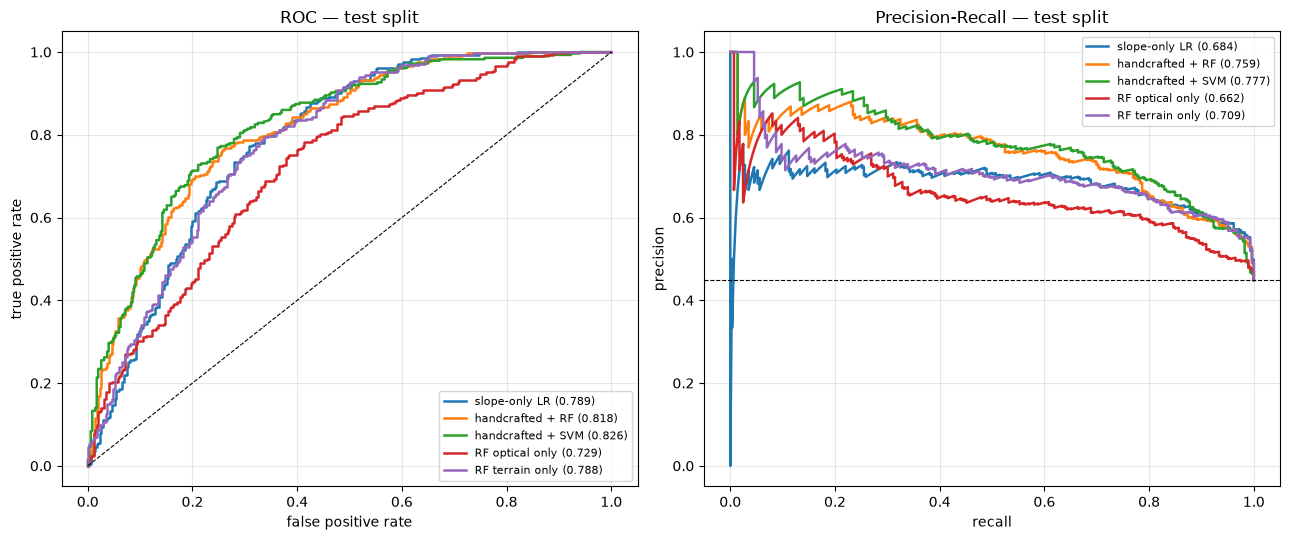

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
for name, p in curves.items():
    fpr, tpr, _ = roc_curve(y[te], p)
    ax[0].plot(fpr, tpr, lw=1.8,
               label=f"{name} ({roc_auc_score(y[te], p):.3f})")
    pr, rc, _ = precision_recall_curve(y[te], p)
    ax[1].plot(rc, pr, lw=1.8,
               label=f"{name} ({average_precision_score(y[te], p):.3f})")

ax[0].plot([0, 1], [0, 1], "k--", lw=.8)
ax[0].set(xlabel="false positive rate", ylabel="true positive rate",
          title="ROC — test split")
ax[1].axhline(y[te].mean(), color="k", ls="--", lw=.8)
ax[1].set(xlabel="recall", ylabel="precision", title="Precision-Recall — test split")
for a in ax:
    a.legend(fontsize=8); a.grid(alpha=.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "08_baseline_curves.png", dpi=130, bbox_inches="tight")
plt.show()

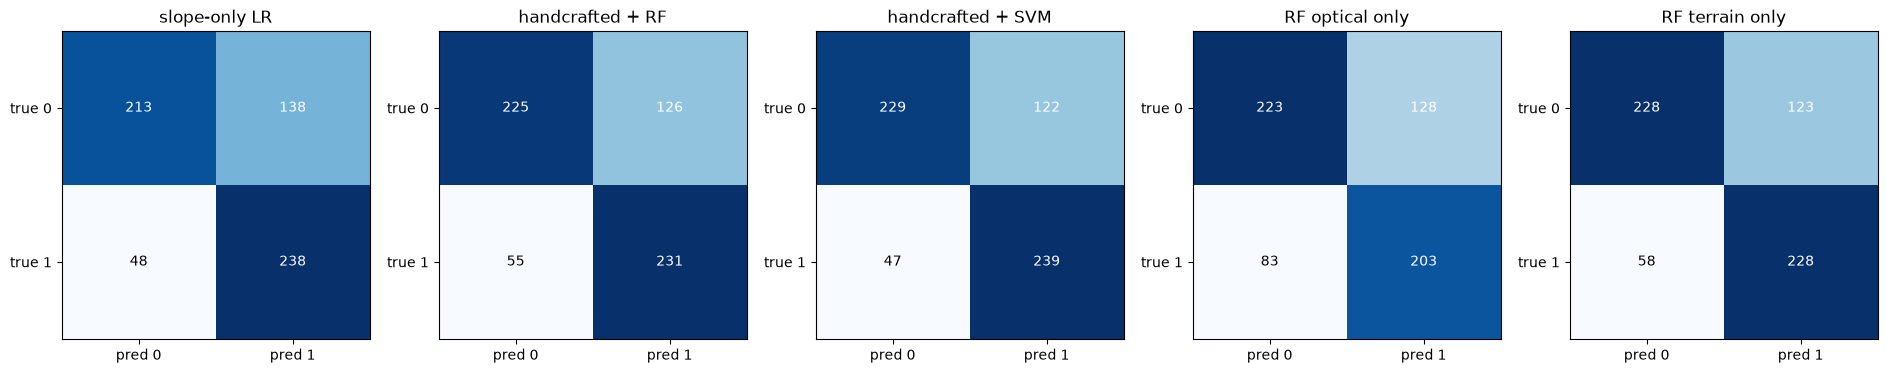

In [17]:
n = len(curves)
fig, axes = plt.subplots(1, n, figsize=(3.8*n, 3.6))
for ax, (name, p) in zip(np.atleast_1d(axes), curves.items()):
    cm = confusion_matrix(y[te], (p >= .5).astype(int), labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black")
    ax.set(title=name, xticks=[0, 1], yticks=[0, 1],
           xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
plt.tight_layout()
plt.savefig(FIG_DIR / "08_baseline_cm.png", dpi=130, bbox_inches="tight")
plt.show()

## Checklist

- [ ] Cell 3  — data loaded, splits verified
- [ ] Cell 4  — slope inversion plausible
- [ ] Cell 7  — LR coefficient POSITIVE; SLOPE_AUC recorded
- [ ] Cell 8  — features finite
- [ ] Cell 10 — terrain features dominate importance
- [ ] Cell 12 — optical vs terrain compared
- [ ] Cell 13 — signal survives elevation matching
- [ ] baselines.csv saved

Commit: "Add majority, slope-only, RF and SVM baselines with elevation-confound test"

Next: 09_train_cnn.ipynb — must beat the slope-only ROC-AUC.